<a href="https://colab.research.google.com/github/Enqosp/riesgo-crediticio-ml/blob/main/credit_risk_dataset_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto final – Implementación de un sistema de Machine Learning
**Estudiante:** Alvaro Enrique Ospino Mantilla  
**Curso:** Machine Learning  
**Fecha:** 28 de mayo de 2026

In [ ]:
# ==============================================================================
# PAUTA 3: DESCRIPCIÓN Y ORGANIZACIÓN DE LOS DATOS
# Configuración del entorno de ejecución y estructura de directorios
# ==============================================================================

import os

# Se define el nombre del directorio usando guion bajo para evitar problemas de rutas
directorio = 'riesgo_crediticio'

# Se crea la carpeta de forma segura. Si ya existe, no hace nada y se evitan errores
os.makedirs(directorio, exist_ok=True)
print(f" Directorio '{directorio}' verificado/creado con éxito.")

 Directorio 'riesgo_crediticio' verificado/creado con éxito.


In [ ]:
# ==============================================================================
# PAUTA 3: DESCRIPCIÓN Y ORGANIZACIÓN DE LOS DATOS
# Subfase: Carga de datos y verificación de dimensiones iniciales
# ==============================================================================
import pandas as pd

# Definimos la ruta del archivo unificado dentro de la carpeta creada
ruta_data = os.path.join(directorio, 'credit_risk_dataset.csv')

try:
    # Carga del dataset en un DataFrame de Pandas
    df = pd.read_csv(ruta_data)
    print(f"Dataset cargado correctamente desde: {ruta_data}")
    print(f"Dimensiones iniciales del dataset: {df.shape[0]} filas y {df.shape[1]} columnas.\n")

    # Visualización de los primeros 5 registros para entender la estructura de los atributos
    print("Primeros 5 registros del conjunto de datos:")
    display(df.head())

except FileNotFoundError:
    print(f"❌ Error: El archivo 'credit_risk_dataset.csv' no se encuentra en la carpeta '{directorio}'.")

Dataset cargado correctamente desde: riesgo_crediticio/credit_risk_dataset.csv
Dimensiones iniciales del dataset: 32581 filas y 12 columnas.

Primeros 5 registros del conjunto de datos:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [ ]:
#===========================================================================
# PAUTA 3: DESCRIPCIÓN Y ORGANIZACIÓN DE LOS DATOS
# Subfase: Diagnóstico de tipos de variables y detección de valores faltantes
#===========================================================================

print("INFORMACIÓN ESTRUCTURAL Y TIPO DE DATOS:")
print("-" * 80)
# Muestra un resumen del tipo de objeto, tipos de datos por columna y uso de memoria
df.info()

INFORMACIÓN ESTRUCTURAL Y TIPO DE DATOS:
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_len

In [ ]:
print("\nCONTEO DE VALORES FALTANTES POR COLUMNA:")
print("-" * 80)
# Calcular la cantidad de nulos por columna y filtrar solo las que tienen nulos
valores_nulos = df.isnull().sum()
print(valores_nulos[valores_nulos > 0] if valores_nulos.sum() > 0 else " ¡No se detectaron valores faltantes!")


CONTEO DE VALORES FALTANTES POR COLUMNA:
--------------------------------------------------------------------------------
person_emp_length     895
loan_int_rate        3116
dtype: int64


In [ ]:
print("\nESTADÍSTICAS DESCRIPTIVAS BÁSICAS (VARIABLES NUMÉRICAS):")
print("-" * 80)
# Inspección rápida de mínimos, máximos y promedios para detectar anomalías visuales
display(df.describe())


ESTADÍSTICAS DESCRIPTIVAS BÁSICAS (VARIABLES NUMÉRICAS):
--------------------------------------------------------------------------------


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [ ]:
# ==============================================================================
# PAUTA 3: DESCRIPCIÓN Y ORGANIZACIÓN DE LOS DATOS
# Identificación y eliminación de registros duplicados
# ==============================================================================

# Calculamos la cantidad de filas idénticas en el dataset
duplicados_totales = df.duplicated().sum()

print("CHEQUEO DE REPETIDOS:")
print("-" * 50)
if duplicados_totales > 0:
    print(f"Se detectaron {duplicados_totales} registros duplicados globales.")
    # Eliminamos duplicados manteniendo la primera ocurrencia
    df = df.drop_duplicates()
    print(f"¡Registros repetidos eliminados! Nuevas dimensiones del dataset: {df.shape}")
else:
    print("Excelente: No se encontraron registros duplicados en el conjunto de datos.")

CHEQUEO DE REPETIDOS:
--------------------------------------------------
Se detectaron 165 registros duplicados globales.
¡Registros repetidos eliminados! Nuevas dimensiones del dataset: (32416, 12)


In [ ]:
# ==============================================================================
# PAUTA 3: DESCRIPCIÓN Y ORGANIZACIÓN DE LOS DATOS
# División del dataset en conjuntos de entrenamiento y prueba
# ==============================================================================
from sklearn.model_selection import train_test_split

# Se separan las variables predictoras (X) de la variable objetivo (y)
X = df.drop(columns=['loan_status'])
y = df['loan_status']

# Se dividen usando 'stratify' para mantener la misma proporción de impagos en ambos sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("AISLAMIENTO DE DATOS COMPLETADO:")
print("-" * 50)
print(f"Set de Entrenamiento (X_train): {X_train.shape[0]} filas | Variables: {X_train.shape[1]}")
print(f"Set de Prueba/Examen (X_test):   {X_test.shape[0]} filas | Variables: {X_test.shape[1]}")

AISLAMIENTO DE DATOS COMPLETADO:
--------------------------------------------------
Set de Entrenamiento (X_train): 25932 filas | Variables: 11
Set de Prueba/Examen (X_test):   6484 filas | Variables: 11


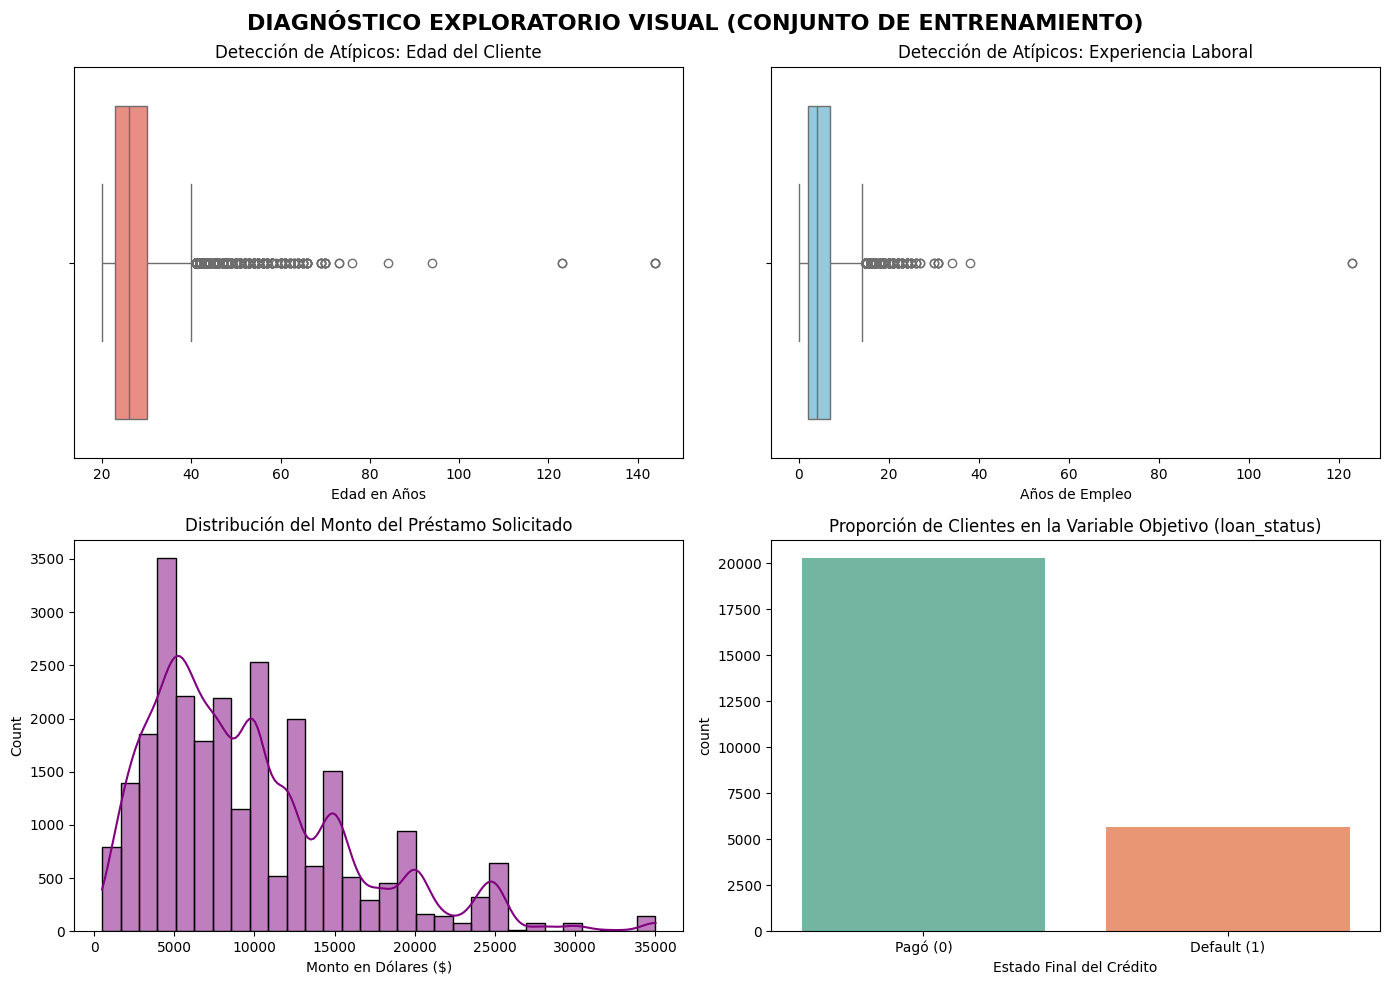

In [ ]:
# ==============================================================================
# PAUTA 3: DESCRIPCIÓN Y ORGANIZACIÓN DE LOS DATOS
# Análisis Exploratorio de Datos EDA - Diagnóstico de Atípicos
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Se unen temporalmente X_train e y_train para facilitar el mapeo en las gráficas
df_train_eda = X_train.copy()
df_train_eda['loan_status'] = y_train

# Configuración del lienzo de gráficos en Colab
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Título principal limpio
fig.suptitle('DIAGNÓSTICO EXPLORATORIO VISUAL (CONJUNTO DE ENTRENAMIENTO)', fontsize=16, fontweight='bold')

# Gráfica 1: Boxplot de Edad
sns.boxplot(ax=axes[0, 0], x=df_train_eda['person_age'], color='salmon')
axes[0, 0].set_title('Detección de Atípicos: Edad del Cliente')
axes[0, 0].set_xlabel('Edad en Años')

# Gráfica 2: Boxplot de Años de Empleo
sns.boxplot(ax=axes[0, 1], x=df_train_eda['person_emp_length'], color='skyblue')
axes[0, 1].set_title('Detección de Atípicos: Experiencia Laboral')
axes[0, 1].set_xlabel('Años de Empleo')

# Gráfica 3: Histograma del Monto Solicitado
sns.histplot(ax=axes[1, 0], x=df_train_eda['loan_amnt'], kde=True, color='purple', bins=30)
axes[1, 0].set_title('Distribución del Monto del Préstamo Solicitado')
axes[1, 0].set_xlabel('Monto en Dólares ($)')

# Gráfica 4: Gráfico de Barras
sns.countplot(
    ax=axes[1, 1],
    x=df_train_eda['loan_status'],
    hue=df_train_eda['loan_status'],
    palette='Set2',
    legend=False
)
axes[1, 1].set_title('Proporción de Clientes en la Variable Objetivo (loan_status)')
axes[1, 1].set_xlabel('Estado Final del Crédito')

# Set_xticklabels fijando primero las posiciones numéricas
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_xticklabels(['Pagó (0)', 'Default (1)'])

plt.tight_layout()
plt.show()

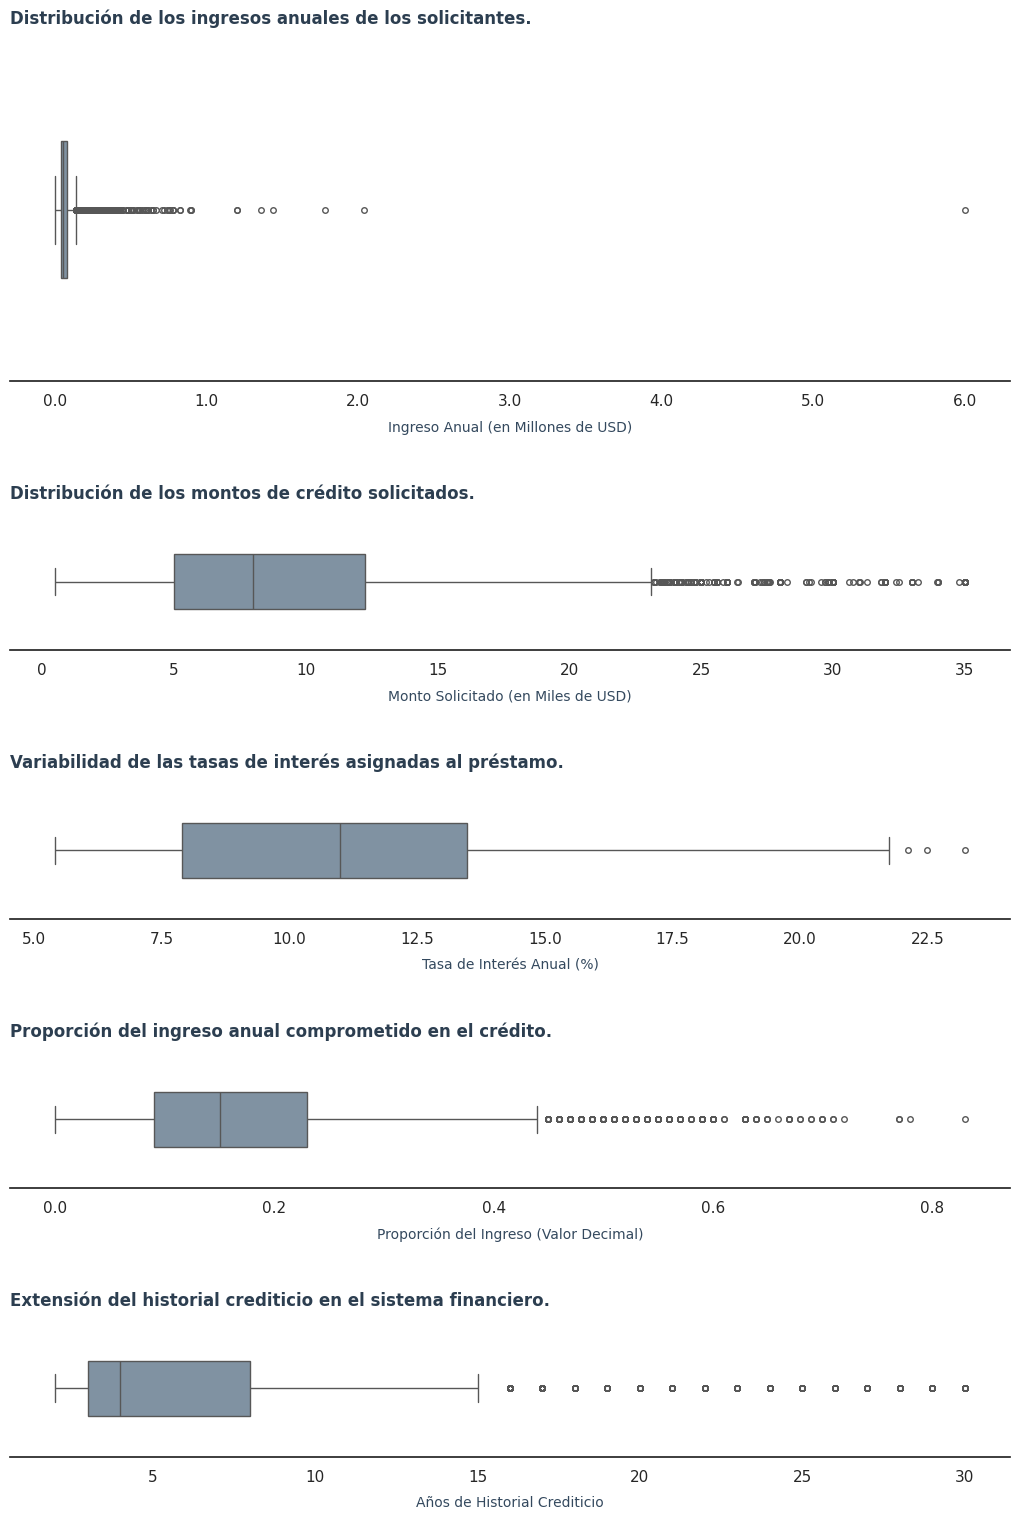

In [ ]:
# ==============================================================================
# PAUTA 3: DESCRIPCIÓN Y ORGANIZACIÓN DE LOS DATOS
# Auditoría Visual de Atípicos
# ==============================================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Configuración de estilo básico y limpio (sin rejillas agresivas, fuentes legibles)
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'

# Variables numéricas a evaluar
variables_analizar = [
    'person_income',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length'
]

# Títulos elegantes y descriptivos (Estilo APA: concisos y explicativos)
titulos = [
    "Distribución de los ingresos anuales de los solicitantes.",
    "Distribución de los montos de crédito solicitados.",
    "Variabilidad de las tasas de interés asignadas al préstamo.",
    "Proporción del ingreso anual comprometido en el crédito.",
    "Extensión del historial crediticio en el sistema financiero."
]

# Etiquetas de los ejes X con unidades totalmente explícitas y entendibles
etiquetas_x = [
    "Ingreso Anual (en Millones de USD)",
    "Monto Solicitado (en Miles de USD)",
    "Tasa de Interés Anual (%)",
    "Proporción del Ingreso (Valor Decimal)",
    "Años de Historial Crediticio"
]

# Se crea el lienzo de 5 filas, 1 columna con un tamaño amplio para evitar saturación
fig, axes = plt.subplots(
    len(variables_analizar),
    1,
    figsize=(11, 16),
    gridspec_kw={'height_ratios': [2.5, 1, 1, 1, 1]}
)

# Se usa una paleta de azul acero muy tenue y elegante, idónea para publicaciones
color_apa = "#7A92A8"

for i, col in enumerate(variables_analizar):
    # Se desactiva el aviso de desuso de paletas asignando los parámetros correctos
    sns.boxplot(ax=axes[i], x=X_train[col], color=color_apa, width=0.4, fliersize=4)

    # Personalización de títulos según pautas formales
    axes[i].set_title(titulos[i], loc='left', fontsize=12, fontweight='bold', pad=10, color="#2C3E50")
    axes[i].set_xlabel(etiquetas_x[i], fontsize=10, labelpad=8, color="#34495E")

    # Se eliminan las líneas innecesarias del recuadro (Spines) para un diseño minimalista
    for spine in ["top", "right", "left"]:
        axes[i].spines[spine].set_visible(False)

    # --- FORMATEO DE LOS EJES Evitar notación científica '1e6'
    if col == 'person_income':
        # Convierte los valores del eje a millones (ej: 2,000,000 -> 2.0)
        axes[i].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}'))
    elif col == 'loan_amnt':
        # Convierte los valores del eje a miles (ej: 20,000 -> 20)
        axes[i].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e3:.0f}'))

# Ajuste general del espacio entre figuras para evitar superposiciones
plt.tight_layout(pad=3.0)
plt.show()

In [ ]:
# ==============================================================================
# PAUTA 3: DESCRIPCIÓN Y ORGANIZACIÓN DE LOS DATOS
# Saneamiento y filtrado de valores atípicos en el set de entrenamiento
# ==============================================================================

# Registrar el volumen de datos original para llevar el control en el informe
filas_antes_filtrado = X_train.shape[0]

# Combinar temporalmente las características con la etiqueta para no perder la sincronía de filas
train_saneamiento = X_train.copy()
train_saneamiento['loan_status'] = y_train

# Aplicar los criterios lógicos validados en nuestro análisis exploratorio:
# - Clientes con edades lógicas, es decir, menores a 90 años
# - Clientes con ingresos representativos para el modelo, es decir menores a 2 millones de USD
# - Años de empleo coherentes - menores a 60 años o valores nulos que se limpiaran después
criterio_saneado = (train_saneamiento['person_age'] < 90) & \
                    (train_saneamiento['person_income'] < 2000000) & \
                    ((train_saneamiento['person_emp_length'] < 60) | (train_saneamiento['person_emp_length'].isnull()))

df_train_saneado = train_saneamiento[criterio_saneado]

# Se reasignan las matrices de entrenamiento oficiales ya purificadas
X_train = df_train_saneado.drop(columns=['loan_status'])
y_train = df_train_saneado['loan_status']

filas_eliminadas = filas_antes_filtrado - X_train.shape[0]

print(" SANEAMIENTO DE MATRICES COMPLETADO:")
print("-" * 60)
print(f"Registros atípicos e inconsistentes eliminados: {filas_eliminadas}")
print(f"Nuevas dimensiones de entrenamiento X_train: {X_train.shape[0]} filas | {X_train.shape[1]} variables")
print(f"Nuevas dimensiones de etiquetas       y_train: {y_train.shape[0]} filas")

 SANEAMIENTO DE MATRICES COMPLETADO:
------------------------------------------------------------
Registros atípicos e inconsistentes eliminados: 9
Nuevas dimensiones de entrenamiento X_train: 25923 filas | 11 variables
Nuevas dimensiones de etiquetas       y_train: 25923 filas


In [ ]:
# ==============================================================================
# PAUTA 3: DESCRIPCIÓN Y ORGANIZACIÓN DE LOS DATOS
# Imputación de valores faltantes mediante la mediana de Train
# ==============================================================================

# Se calculan las medianas estadísticas unicamente en el set de entrenamiento
mediana_empleo = X_train['person_emp_length'].median()
mediana_tasa = X_train['loan_int_rate'].median()

print(" VALORES DE IMPUTACIÓN CALCULADOS - SOLO TRAIN:")
print("-" * 60)
print(f"Mediana para años de empleo - person_emp_length: {mediana_empleo} años")
print(f"Mediana para tasa de interés - loan_int_rate:    {round(mediana_tasa, 2)}%")

# Se aplica la imputación en el Set de Entrenamiento X_train
X_train['person_emp_length'] = X_train['person_emp_length'].fillna(mediana_empleo)
X_train['loan_int_rate'] = X_train['loan_int_rate'].fillna(mediana_tasa)

# Se aplican excatamente las mismas medianas en el Set de Prueba X_test para evitar fuga de datos
X_test['person_emp_length'] = X_test['person_emp_length'].fillna(mediana_empleo)
X_test['loan_int_rate'] = X_test['loan_int_rate'].fillna(mediana_tasa)

print("\nVERIFICACIÓN FINAL DE NULOS POST-IMPUTACIÓN:")
print("-" * 60)
print(f"Nulos pendientes en X_train: {X_train.isnull().sum().sum()}")
print(f"Nulos pendientes en X_test:  {X_test.isnull().sum().sum()}")

 VALORES DE IMPUTACIÓN CALCULADOS - SOLO TRAIN:
------------------------------------------------------------
Mediana para años de empleo - person_emp_length: 4.0 años
Mediana para tasa de interés - loan_int_rate:    10.99%

VERIFICACIÓN FINAL DE NULOS POST-IMPUTACIÓN:
------------------------------------------------------------
Nulos pendientes en X_train: 0
Nulos pendientes en X_test:  0


In [ ]:
# ==============================================================================
# PAUTA 3: DESCRIPCIÓN Y ORGANIZACIÓN DE LOS DATOS
# Codificación de variables categóricas mediante One-Hot Encoding
# ==============================================================================
import pandas as pd

# Se listan las columnas de tipo texto que se identificaron en el análisis exploratorio
columnas_categoricas = [
    'person_home_ownership',
    'loan_intent',
    'loan_grade',
    'cb_person_default_on_file'
]

# Se aplica One-Hot Encoding de forma sincronizada y segura
# Se usa drop_first=True para evitar la trampa de la multicolinealidad
X_train_encoded = pd.get_dummies(X_train, columns=columnas_categoricas, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=columnas_categoricas, drop_first=True)

# Asegurar que ambos conjuntos tengan exactamente el mismo orden y nombres de columnas
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# Convertir los valores booleanos True/False que genera Pandas a binarios puros 1/0
X_train_encoded = X_train_encoded.astype(float)
X_test_encoded = X_test_encoded.astype(float)

print(" CODIFICACIÓN CATEGÓRICA COMPLETADA:")
print("-" * 60)
print(f" Nuevas dimensiones de entrenamiento (X_train_encoded): {X_train_encoded.shape}")
print(f" Nuevas dimensiones de prueba        (X_test_encoded):  {X_test_encoded.shape}")
print(f" Total de variables finales para el modelo: {X_train_encoded.shape[1]}")

 CODIFICACIÓN CATEGÓRICA COMPLETADA:
------------------------------------------------------------
 Nuevas dimensiones de entrenamiento (X_train_encoded): (25923, 22)
 Nuevas dimensiones de prueba        (X_test_encoded):  (6484, 22)
 Total de variables finales para el modelo: 22


In [ ]:
# ==============================================================================
# PAUTA 4: METODOLOGÍA
# Inicialización y entrenamiento de Modelos de Conjunto - Ensembles
# ==============================================================================
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
import time

print("INICIANDO EL ENTRENAMIENTO DE MODELOS DE CONJUNTO:")
print("-" * 70)

# Configuración y Ajuste del Modelo Random Forest
# Ajustar max_depth=12 y class_weight='balanced' para contrarrestar el desbalance de clases
rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("Entrenando Modelo Random Forest...")
inicio_rf = time.time()
rf_model.fit(X_train_encoded, y_train)
tiempo_rf = time.time() - inicio_rf
print(f"Random Forest entrenado con éxito en {tiempo_rf:.2f} segundos.")

# Configuración y Ajuste del Modelo LightGBM
# Usar scale_pos_weight para balancear penalizaciones en el cálculo del gradiente secuencial
lgb_model = lgb.LGBMClassifier(
    n_estimators=150,
    max_depth=8,
    learning_rate=0.05,
    scale_pos_weight=3.5, # Ajuste proporcional basado en el desbalance observado en el EDA
    random_state=42,
    n_jobs=-1,
    verbose=-1 # Desactivar mensajes internos de depuración de la librería
)

print("\nEntrenando Modelo LightGBM...")
inicio_lgb = time.time()
lgb_model.fit(X_train_encoded, y_train)
tiempo_lgb = time.time() - inicio_lgb
print(f"LightGBM entrenado con éxito en {tiempo_lgb:.2f} segundos.")

INICIANDO EL ENTRENAMIENTO DE MODELOS DE CONJUNTO:
----------------------------------------------------------------------
Entrenando Modelo Random Forest...
Random Forest entrenado con éxito en 2.56 segundos.

Entrenando Modelo LightGBM...
LightGBM entrenado con éxito en 0.49 segundos.


In [ ]:
# ==============================================================================
# PAUTA 5: RESULTADOS
# Evaluación comparativa de modelos en el conjunto de prueba - Test
# ==============================================================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd

# Generar las predicciones en el set de prueba para ambos modelos
y_pred_rf = rf_model.predict(X_test_encoded)
y_pred_lgb = lgb_model.predict(X_test_encoded)

# Computar las métricas para Random Forest
metricas_rf = {
    'Modelo': 'Random Forest (Bagging)',
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1-Score': f1_score(y_test, y_pred_rf)
}

# Computar las métricas para LightGBM
metricas_lgb = {
    'Modelo': 'LightGBM (Boosting)',
    'Accuracy': accuracy_score(y_test, y_pred_lgb),
    'Precision': precision_score(y_test, y_pred_lgb),
    'Recall': recall_score(y_test, y_pred_lgb),
    'F1-Score': f1_score(y_test, y_pred_lgb)
}

# Construir un DataFrame comparativo para la visualización
df_comparativo = pd.DataFrame([metricas_rf, metricas_lgb]).set_index('Modelo')

print("TABLA COMPARATIVA DE RENDIMIENTO - CONJUNTO DE PRUEBA:")
print("-" * 80)
display(df_comparativo.round(4))

print("\nMATRICES DE CONFUSIÓN:")
print("-" * 80)
print("Matriz de Confusión - Random Forest:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nMatriz de Confusión - LightGBM:")
print(confusion_matrix(y_test, y_pred_lgb))

TABLA COMPARATIVA DE RENDIMIENTO - CONJUNTO DE PRUEBA:
--------------------------------------------------------------------------------


,Accuracy,Precision,Recall,F1-Score
Modelo,,,,
Random Forest (Bagging),0.9210,0.8813,0.7384,0.8035
LightGBM (Boosting),0.9132,0.8127,0.7835,0.7978



MATRICES DE CONFUSIÓN:
--------------------------------------------------------------------------------
Matriz de Confusión - Random Forest:
[[4925  141]
 [ 371 1047]]

Matriz de Confusión - LightGBM:
[[4810  256]
 [ 307 1111]]


In [ ]:
# ==============================================================================
# PAUTA 7: CONCLUSIONES Y RECOMENDACIONES
# Exportación del modelo ganador y cierre del flujo de trabajo
# ==============================================================================
import joblib
import os

print("CONFIGURANDO ALMACENAMIENTO DEL MODELO GANADOR:")
print("-" * 70)

# Definir la ruta de exportación dentro de nuestra estructura organizada
ruta_modelo_ganador = os.path.join('riesgo_crediticio', 'modelo_ganador_lightgbm.pkl')

# Guardar el modelo entrenado en un archivo binario portable
joblib.dump(lgb_model, ruta_modelo_ganador)

print(f" ¡Modelo LightGBM exportado correctamente en: '{ruta_modelo_ganador}'!")
print(" El archivo .pkl está listo para ser desplegado en una API o entorno de producción.")
print("\n" + "="*70)
print(" ¡PROYECTO DE CIENCIA DE DATOS CONSTRUIDO CON ÉXITO!")
print("="*70)

CONFIGURANDO ALMACENAMIENTO DEL MODELO GANADOR:
----------------------------------------------------------------------
 ¡Modelo LightGBM exportado correctamente en: 'riesgo_crediticio/modelo_ganador_lightgbm.pkl'!
 El archivo .pkl está listo para ser desplegado en una API o entorno de producción.

 ¡PROYECTO DE CIENCIA DE DATOS CONSTRUIDO CON ÉXITO!
